In [2]:
# !uv pip install matplotlib

In [3]:
# Analysis for usage_log.csv (from ResourceMonitor)
# Outputs:
#   - analysis_summary.json : high-level stats
#   - spikes.csv            : detected CPU / RAM spikes with start/end/duration
#   - fig_cpu.png           : system & process CPU timeline
#   - fig_mem.png           : system % & process MB timeline
#   - cleaned.parquet       : cleaned dataframe with rolling metrics

import json
import math
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def main(csv_path):
    # ---------- Config ----------
    CSV_PATH = Path(csv_path)
    TIME_COL = "timestamp"
    ROLL = "30s"          # time-based rolling window
    RESAMPLE = "1s"       # resample cadence for clean timelines
    TOP_N_PEAKS = 5
    CPU_SPIKE_SYS = 85.0  # %
    CPU_SPIKE_PROC = 300.0  # % of a single core; can exceed 100 on multi-core
    MEM_SPIKE_SYS = 90.0  # %
    MEM_SPIKE_PROC_MB_JUMP = 500  # MB jump within the rolling window
    SUSTAINED_SECS = 3    # min duration (in seconds) to call something a sustained spike
    
    # ---------- Load & clean ----------
    df_raw = pd.read_csv(CSV_PATH)
    if TIME_COL not in df_raw.columns:
        raise ValueError(f"Expected a '{TIME_COL}' column (ISO time strings). Found: {df_raw.columns.tolist()}")
    
    # Parse time, sort, and set index
    df = df_raw.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).set_index(TIME_COL)
    
    # Ensure expected columns exist
    expected_cols = ["proc_cpu_pct", "proc_mem_mb", "sys_cpu_pct", "sys_mem_pct"]
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}. Found columns: {df.columns.tolist()}")
    
    # Resample to regular grid for clean rolling calculations
    df_res = (df
              .resample(RESAMPLE)
              .mean()
              .interpolate("time", limit_direction="both"))
    
    # Rolling stats (time-based windows)
    df_res["proc_cpu_roll"] = df_res["proc_cpu_pct"].rolling(ROLL, min_periods=1).mean()
    df_res["sys_cpu_roll"]  = df_res["sys_cpu_pct"].rolling(ROLL, min_periods=1).mean()
    df_res["proc_mem_roll"] = df_res["proc_mem_mb"].rolling(ROLL, min_periods=1).mean()
    df_res["sys_mem_roll"]  = df_res["sys_mem_pct"].rolling(ROLL, min_periods=1).mean()
    
    # Derivatives / growth rates (MB per minute)
    dt_sec = df_res.index.to_series().diff().dt.total_seconds().fillna(0).replace(0, np.nan)
    dmem_mb = df_res["proc_mem_mb"].diff()
    df_res["proc_mem_mb_per_min"] = (dmem_mb / dt_sec) * 60.0
    
    # ---------- Helper: find sustained intervals above threshold ----------
    def sustained_intervals(series: pd.Series, threshold: float, min_secs: int) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
        mask = series > threshold
        if mask.sum() == 0:
            return []
        groups = (mask != mask.shift()).cumsum()
        out = []
        for g, seg in series.groupby(groups):
            if not seg.index.size: 
                continue
            if (seg.index.size * pd.to_timedelta(RESAMPLE).total_seconds()) >= min_secs and (seg > threshold).all():
                out.append((seg.index[0], seg.index[-1]))
        return out
    
    # ---------- Spike detection ----------
    sys_cpu_spikes = sustained_intervals(df_res["sys_cpu_pct"], CPU_SPIKE_SYS, SUSTAINED_SECS)
    proc_cpu_spikes = sustained_intervals(df_res["proc_cpu_pct"], CPU_SPIKE_PROC, SUSTAINED_SECS)
    sys_mem_spikes = sustained_intervals(df_res["sys_mem_pct"], MEM_SPIKE_SYS, SUSTAINED_SECS)
    
    # Memory jump spikes for process (uses rolling diff)
    roll_win = int(pd.to_timedelta(ROLL).total_seconds() / pd.to_timedelta(RESAMPLE).total_seconds())
    mem_jump = df_res["proc_mem_mb"].diff(roll_win).fillna(0)
    proc_mem_jump_spikes = sustained_intervals(mem_jump, MEM_SPIKE_PROC_MB_JUMP, SUSTAINED_SECS)
    
    # Top peaks (by absolute value)
    def top_peaks(series: pd.Series, n=TOP_N_PEAKS):
        s = series.dropna()
        idx = s.nlargest(min(n, len(s))).index
        return pd.DataFrame({
            "timestamp": idx,
            "value": s.loc[idx].values
        }).sort_values("value", ascending=False)
    
    top_sys_cpu = top_peaks(df_res["sys_cpu_pct"])
    top_proc_cpu = top_peaks(df_res["proc_cpu_pct"])
    top_sys_mem = top_peaks(df_res["sys_mem_pct"])
    top_proc_mem = top_peaks(df_res["proc_mem_mb"])
    
    # Memory trend via robust linear fit (Theil-Sen or fallback to polyfit)
    try:
        import statsmodels.api as sm
        t_sec = (df_res.index - df_res.index[0]).total_seconds()
        X = sm.add_constant(t_sec)
        model = sm.RLM(df_res["proc_mem_mb"], X, M=sm.robust.norms.HuberT())
        res = model.fit()
        slope_mb_per_min = res.params[1] * 60.0
    except Exception:
        # fallback: simple polyfit
        t_sec = (df_res.index - df_res.index[0]).total_seconds().astype(float)
        if len(t_sec) >= 2:
            m, b = np.polyfit(t_sec, df_res["proc_mem_mb"].values, 1)
            slope_mb_per_min = m * 60.0
        else:
            slope_mb_per_min = float("nan")
    
    # Sampling stats
    if len(df) > 1:
        raw_gaps = df.index.to_series().diff().dt.total_seconds().dropna()
        median_dt = float(raw_gaps.median())
        missing_ratio = float((df_res.shape[0] - df.shape[0]) / df_res.shape[0])
    else:
        median_dt = float("nan")
        missing_ratio = 0.0
    
    # ---------- Assemble spike table ----------
    def intervals_to_df(name, intervals, series):
        rows = []
        for s, e in intervals:
            seg = series.loc[s:e]
            rows.append({
                "type": name,
                "start": s,
                "end": e,
                "duration_s": (e - s).total_seconds(),
                "max_value": float(seg.max()),
                "avg_value": float(seg.mean()),
            })
        return pd.DataFrame(rows)
    
    spike_rows = []
    spike_rows.append(intervals_to_df("sys_cpu_pct>="+str(CPU_SPIKE_SYS), sys_cpu_spikes, df_res["sys_cpu_pct"]))
    spike_rows.append(intervals_to_df("proc_cpu_pct>="+str(CPU_SPIKE_PROC), proc_cpu_spikes, df_res["proc_cpu_pct"]))
    spike_rows.append(intervals_to_df("sys_mem_pct>="+str(MEM_SPIKE_SYS), sys_mem_spikes, df_res["sys_mem_pct"]))
    # For mem jumps, report the end-point memory level too
    rows = []
    for s, e in proc_mem_jump_spikes:
        seg = mem_jump.loc[s:e]
        rows.append({
            "type": f"proc_mem_jump>={MEM_SPIKE_PROC_MB_JUMP}MB/{ROLL}",
            "start": s,
            "end": e,
            "duration_s": (e - s).total_seconds(),
            "max_jump_mb": float(seg.max()),
            "proc_mem_mb_end": float(df_res.loc[e, "proc_mem_mb"]),
        })
    spike_rows.append(pd.DataFrame(rows))
    spikes_df = pd.concat([r for r in spike_rows if r is not None and not r.empty], ignore_index=True) if any(
        r is not None and not r.empty for r in spike_rows
    ) else pd.DataFrame(columns=["type","start","end","duration_s","max_value","avg_value","max_jump_mb","proc_mem_mb_end"])
    
    # ---------- Summary ----------
    summary = {
        "file": str(CSV_PATH),
        "start": df_res.index.min().isoformat() if len(df_res) else None,
        "end": df_res.index.max().isoformat() if len(df_res) else None,
        "duration_minutes": round((df_res.index.max() - df_res.index.min()).total_seconds() / 60.0, 2) if len(df_res) else 0.0,
        "raw_samples": int(df.shape[0]),
        "clean_samples": int(df_res.shape[0]),
        "median_raw_sampling_interval_s": None if math.isnan(median_dt) else round(median_dt, 3),
        "estimated_missing_ratio": round(missing_ratio, 3),
        "top_peaks": {
            "sys_cpu_pct": top_sys_cpu.to_dict(orient="records"),
            "proc_cpu_pct": top_proc_cpu.to_dict(orient="records"),
            "sys_mem_pct": top_sys_mem.to_dict(orient="records"),
            "proc_mem_mb": top_proc_mem.to_dict(orient="records"),
        },
        "spike_counts": {
            "sys_cpu_sustained": len(sys_cpu_spikes),
            "proc_cpu_sustained": len(proc_cpu_spikes),
            "sys_mem_sustained": len(sys_mem_spikes),
            "proc_mem_jumps": len(proc_mem_jump_spikes),
        },
        "proc_mem_trend_mb_per_min": round(float(slope_mb_per_min), 3) if not math.isnan(slope_mb_per_min) else None,
        "thresholds": {
            "CPU_SPIKE_SYS_pct": CPU_SPIKE_SYS,
            "CPU_SPIKE_PROC_pct": CPU_SPIKE_PROC,
            "MEM_SPIKE_SYS_pct": MEM_SPIKE_SYS,
            "PROC_MEM_JUMP_MB_in_window": MEM_SPIKE_PROC_MB_JUMP,
            "ROLL_window": ROLL,
            "RESAMPLE": RESAMPLE,
            "SUSTAINED_secs": SUSTAINED_SECS,
        }
    }
    
    # ---------- Save artifacts ----------
    df_res.to_parquet("cleaned.parquet")
    if not spikes_df.empty:
        spikes_df.to_csv("spikes.csv", index=False)
    with open("analysis_summary.json", "w") as f:
        json.dump(summary, f, indent=2, default=str)
    
    # ---------- Plots ----------
    def finalize_axes(ax, title, ylabel):
        ax.set_title(title)
        ax.set_xlabel("time")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    
    # CPU plot (system + process)
    plt.figure(figsize=(11, 5))
    plt.plot(df_res.index, df_res["sys_cpu_pct"], label="system CPU %")
    plt.plot(df_res.index, df_res["sys_cpu_roll"], label=f"system CPU % ({ROLL} roll)")
    plt.plot(df_res.index, df_res["proc_cpu_pct"], label="process CPU %")
    plt.plot(df_res.index, df_res["proc_cpu_roll"], label=f"process CPU % ({ROLL} roll)")
    plt.axhline(CPU_SPIKE_SYS, linestyle="--", linewidth=1, label=f"sys CPU spike @ {CPU_SPIKE_SYS}%")
    plt.axhline(CPU_SPIKE_PROC, linestyle="--", linewidth=1, label=f"proc CPU spike @ {CPU_SPIKE_PROC}%")
    finalize_axes(plt.gca(), "CPU Utilization Over Time", "percent")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("fig_cpu.png", dpi=160)
    plt.show()
        
    # Memory plot (process RAM only, MB)
    plt.figure(figsize=(11, 5))
    plt.plot(df_res.index, df_res["proc_mem_mb"], label="process RAM (MB)")
    plt.plot(df_res.index, df_res["proc_mem_roll"], label=f"process RAM (MB) ({ROLL} roll)")
    finalize_axes(plt.gca(), "Process Memory Over Time", "MB")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("fig_mem.png", dpi=160)
    plt.show()

    
    # ---------- Human-readable printouts ----------
    from pprint import pprint
    print("\n=== SUMMARY ===")
    pprint(summary)
    print("\n=== TOP PEAKS (head) ===")
    print("System CPU %:\n", top_sys_cpu.head())
    print("\nProcess CPU %:\n", top_proc_cpu.head())
    print("\nSystem Mem %:\n", top_sys_mem.head())
    print("\nProcess Mem MB:\n", top_proc_mem.head())
    print("\n=== SPIKES (first 10) ===")
    print(spikes_df.head(10) if not spikes_df.empty else "(none)")


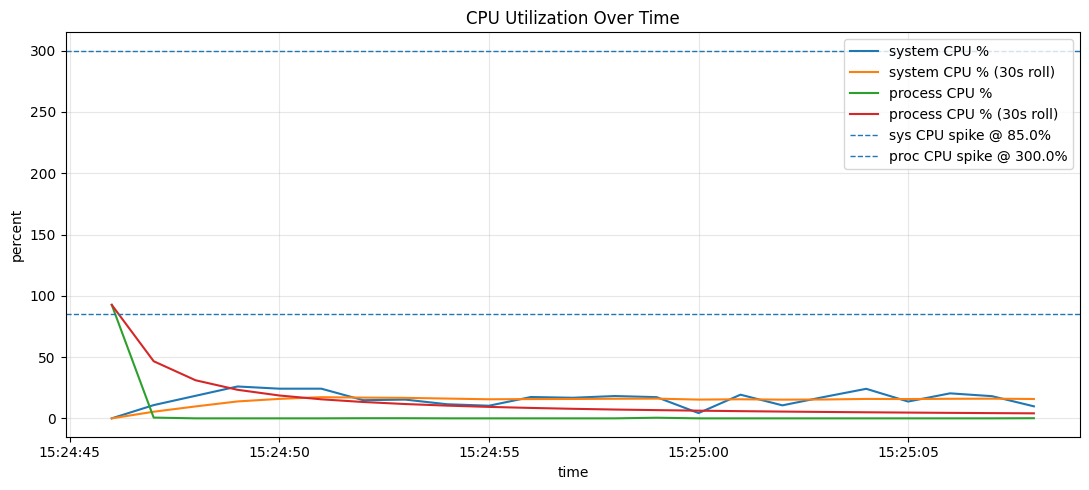

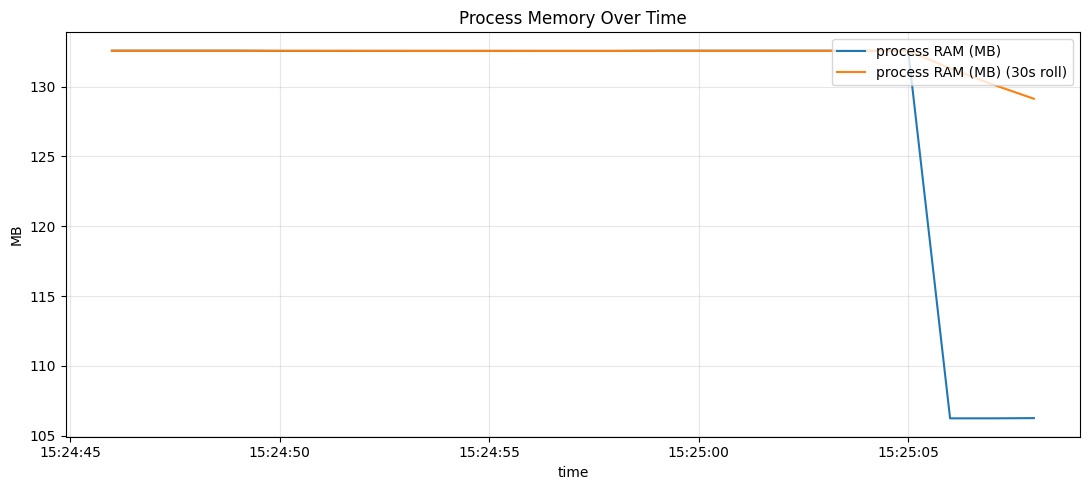


=== SUMMARY ===
{'clean_samples': 23,
 'duration_minutes': 0.37,
 'end': '2025-10-03T15:25:08',
 'estimated_missing_ratio': 0.0,
 'file': 'usage_log_empty.csv',
 'median_raw_sampling_interval_s': 1.0,
 'proc_mem_trend_mb_per_min': -46.821,
 'raw_samples': 23,
 'spike_counts': {'proc_cpu_sustained': 0,
                  'proc_mem_jumps': 0,
                  'sys_cpu_sustained': 0,
                  'sys_mem_sustained': 0},
 'start': '2025-10-03T15:24:46',
 'thresholds': {'CPU_SPIKE_PROC_pct': 300.0,
                'CPU_SPIKE_SYS_pct': 85.0,
                'MEM_SPIKE_SYS_pct': 90.0,
                'PROC_MEM_JUMP_MB_in_window': 500,
                'RESAMPLE': '1s',
                'ROLL_window': '30s',
                'SUSTAINED_secs': 3},
 'top_peaks': {'proc_cpu_pct': [{'timestamp': Timestamp('2025-10-03 15:24:46'),
                                 'value': 92.6},
                                {'timestamp': Timestamp('2025-10-03 15:24:47'),
                                 'valu

In [4]:
main("usage_log_empty.csv")

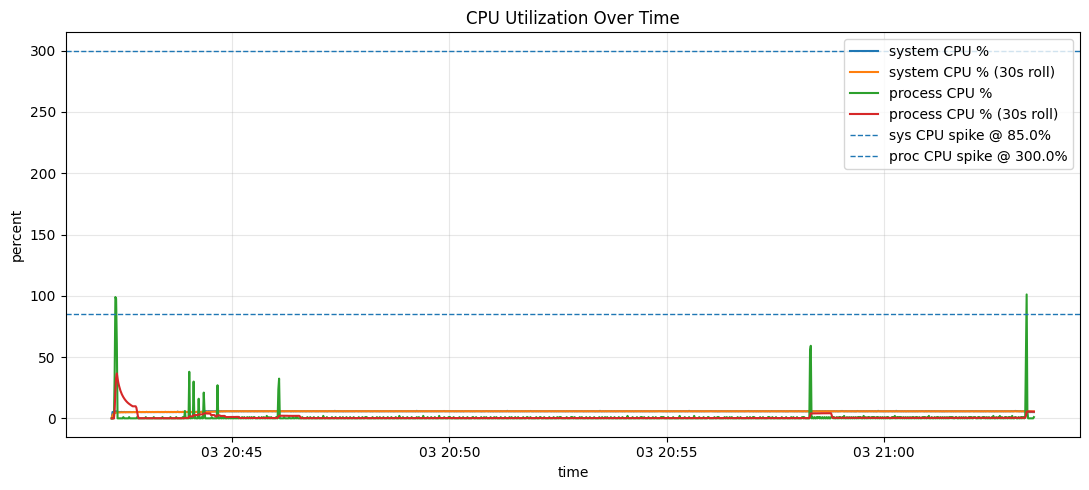

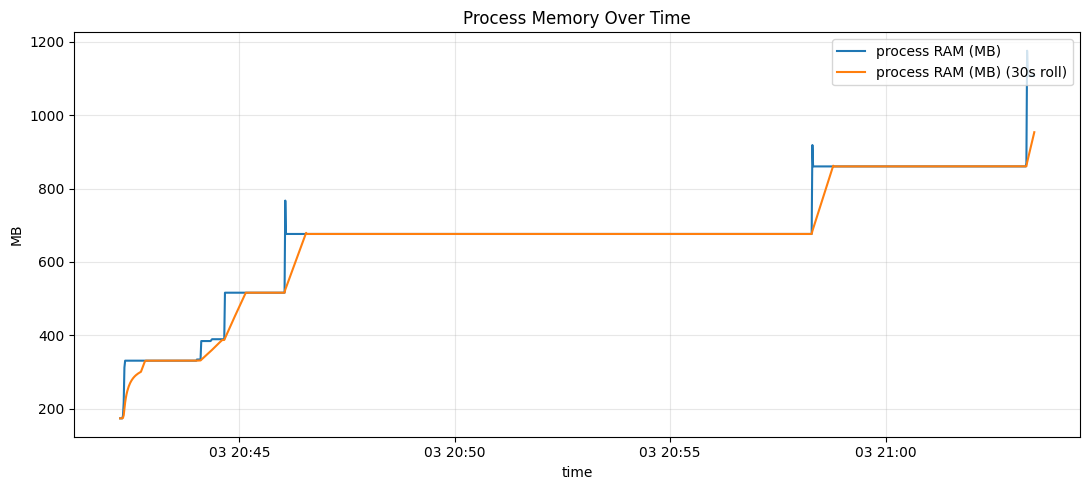


=== SUMMARY ===
{'clean_samples': 1274,
 'duration_minutes': 21.22,
 'end': '2025-10-03T21:03:27',
 'estimated_missing_ratio': 0.0,
 'file': 'usage_log_1.csv',
 'median_raw_sampling_interval_s': 1.0,
 'proc_mem_trend_mb_per_min': 22.036,
 'raw_samples': 1274,
 'spike_counts': {'proc_cpu_sustained': 0,
                  'proc_mem_jumps': 0,
                  'sys_cpu_sustained': 0,
                  'sys_mem_sustained': 0},
 'start': '2025-10-03T20:42:14',
 'thresholds': {'CPU_SPIKE_PROC_pct': 300.0,
                'CPU_SPIKE_SYS_pct': 85.0,
                'MEM_SPIKE_SYS_pct': 90.0,
                'PROC_MEM_JUMP_MB_in_window': 500,
                'RESAMPLE': '1s',
                'ROLL_window': '30s',
                'SUSTAINED_secs': 3},
 'top_peaks': {'proc_cpu_pct': [{'timestamp': Timestamp('2025-10-03 21:03:17'),
                                 'value': 101.1},
                                {'timestamp': Timestamp('2025-10-03 20:42:19'),
                                 'val

In [5]:
main("usage_log_1.csv")